# Custom Climate Profiles Generation

#### Step 0: Set-Up
Import the [climakitae](https://github.com/cal-adapt/climakitae) library and other dependencies.

In [1]:
from climakitae.explore.standard_year_profile import (
    get_climate_profile,
    export_profile_to_csv,
)
from climakitae.explore.shock_extreme_meteorological_year import shock_XMY
from climakitae.core.data_interface import get_subsetting_options

import warnings

warnings.filterwarnings("ignore")

In [2]:
n_years = 3
years = list(range(2001, 2001 + n_years))

In [4]:
import numpy as np
import pandas as pd
import pytest
import xarray as xr
from scipy.optimize import OptimizeWarning

In [12]:
time_index = pd.date_range(start="2001-01-01", end="2003-12-31")

test_data = np.arange(0, 365 * 3, 1)
test_data = test_data * np.ones((2, len(test_data)))
test_ds = xr.DataArray(
    name="temperature",
    data=test_data,
    coords={
        "simulation": ["sim1", "sim2"],
        "time": time_index,
    },
).to_dataset()

min_temp = test_data.copy()
min_temp[:, time_index.year == 2002] -= 1000
test_ds["Daily min air temperature"] = (["simulation", "time"], min_temp)

# now add in max air temp data, in which the final two years have the highest temperatures
max_temp = test_data.copy()
max_temp[:, time_index.year == 2003] += 1000
test_ds["Daily max air temperature"] = (["simulation", "time"], max_temp)

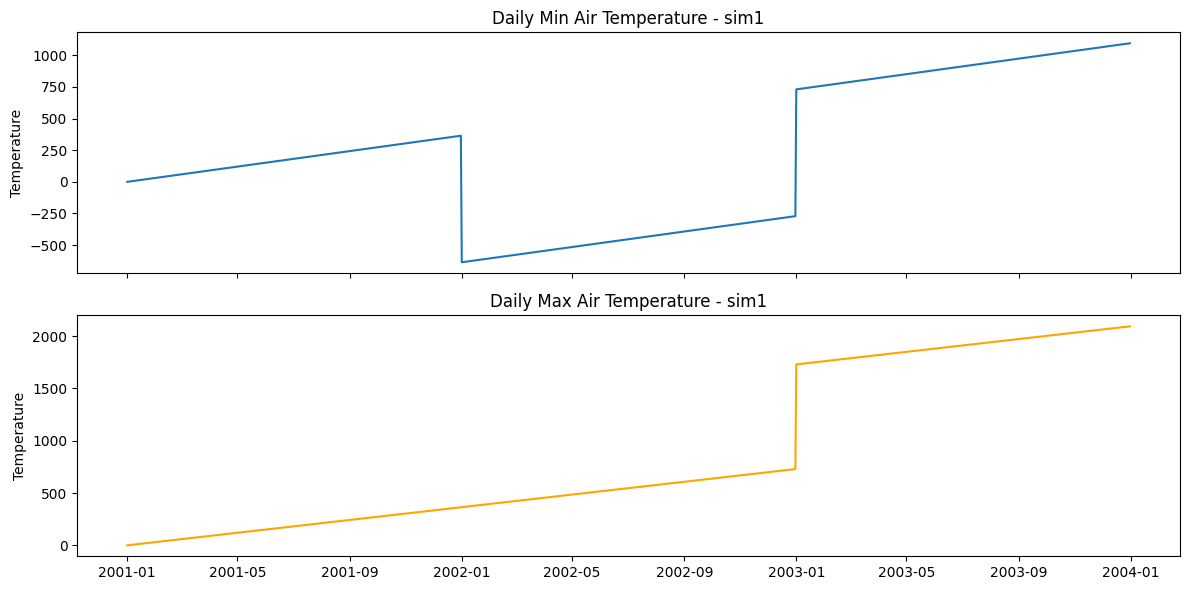

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(time_index, min_temp[0], label="Daily min air temperature")
axes[0].set_title("Daily Min Air Temperature - sim1")
axes[0].set_ylabel("Temperature")

axes[1].plot(time_index, max_temp[0], label="Daily max air temperature", color="orange")
axes[1].set_title("Daily Max Air Temperature - sim1")
axes[1].set_ylabel("Temperature")

plt.tight_layout()
plt.show()

### Generate a Shock XMY

In [ ]:
# Set up the TMY profile generator! The verbose option will output progress of the TMY generation
xmy = shock_XMY(
    extreme ='hot',
    start_year = 2005,
    end_year = 2020,
    # warming_level = 
    station_name = "Los Angeles International Airport (KLAX)",
    verbose = True,
)

# Generate the profile!
xmy.generate_xmy()

**Export to non-EPW format.** TMY profiles are exported in .epw format by default, but can be exported as both `.csv` and `.tmy` file formats using the method `export_tmy_data` with the argument `extension="csv"` as shown below.

In [ ]:
xmy.export_xmy_data(extension="csv")